___

# ZNE - Zero Noise Extrapolation

Essa técnica de correção de erros consiste em estimar o valor ideal sem erro para um valor estimado baseado em um parâmetro λ que é responsável por quantizar o erro de um circuito quântico. Para implementar o ZNE é então necessário encontrar um método rigoroso e reprodutível para aumentar o erro de um circuito quântico de maneira padronizada e logo determinar o valor esperado para cada nível de erro λ, E(λ). Sendo assim, podemos implementar o ZNE seguindo esses 2 passos: 

1. **Noise-Scaling** : Medir E(λ) para *m* distintos valores de λ ≥ 1.

2. **Extrapolation** : Inferir E(λ = 0) utilizando os *m* valores esperados determinados no passo anterior.

___

## Noise Scaling Methods 

Assim como discutimos anteriormente, é necessário encontrar um método para aumentar sistematicamente o erro de um circuito quântico. Existem diversas possibilidades para fazer isso, porém aqui utilizaremos uma técnica de **gate-folding** assim como uma técnica que envolve escalar o ruido utilizando **parâmetros** de gates quânticos. 

### A. Unitary Folding

Essa técnica utiliza o seguinte fato para aumentar o tamanho de um circuito quântico:

$$U \rightarrow U(U^{\dagger}U)^n$$

Dado que $U^{\dagger}U = I$, por definição. Sendo assim, podemos utilizar essa técnica para aumentar o tamanho de um circuito quântico e, dessa forma, aumentar o erro do circuito e escalar o parâmetro λ, dado que o número de operações aumenta com um fator de $1 + 2n$. Aqui o operador $U$ pode representar tanto *gates* unitários quanto o próprio circuito quântico inteiro. 

#### 1. Circuit Folding

Seja o circuito quântico representado por: 

$$U = L_{d}...L_{2}L_{1}$$

Onde $d$ é o *depth* do *qc*, circuito quântico, e cada $L_{n}$ representa uma *layer* do circuito, que pode ser um gate ou um conjunto de gates. Quando realizamos um circuit-folding do qc completo, multiplicamos o depth por um fator de $1 + 2n$, assumindo que temos um depth original de $d$:

$$
[U] = d \quad \therefore \quad [U^\dagger U] = d + d = 2d
\\~\\
[U(U^{\dagger}U)^n] = d + n(2d) = d (1 + 2n)
$$

Sendo assim, como $1 + 2n$ é sempre um número ímpar, o fator pelo qual multiplicamos o depth do qc sempre será ímpar. Para mitigar isso, estabeleceremos a seguinte regra de folding chamada de *partial-folding*: 

$$
U \rightarrow U(U^{\dagger}U)^n L_{d}^\dagger L_{d-1}^\dagger ... L_{s}^\dagger L_{s} ... L_{d-1}L_{d} = U'

\\~\\

[U'] = d (1 + 2n) + (d - s) + (s - d) = d (1 + 2n) + 2s 
$$

Com esse novo depth de $d (1 + 2n) + 2s$ temos uma possibilidade maior de escolher o valor de λ

___

> Para criar esse código utilizaremos a função [random_circuit](https://quantum.cloud.ibm.com/docs/en/api/qiskit/circuit_random) para gerar qc aleatórios para teste

Vamos criar a própria função para gerar circuitos aleatórios que possa ser customizada a fim de incluir apenas os gates que queremos, dado que precisamos de circuitos quânticos em que todos os seus gates admitam um inverso. Isso é trivial em princípio, dado que todos os gates quânticos são unitários e portanto reversíveis, porém, como estamos lidando com computadores quânticos que admitem apenas alguns gates, existe a possibilidade de que um computador quântico específico não possua suporte para o correspondente *dagger* do próprio gate.

In [1]:
from Requirements import *

In [10]:
def qc_generator(num_qubits, depth, clifford = False, gates = None, measure = None, distribution = 0.7) :

    """
    Gera um circuito quântico aleatório utilizando gates de 1 ou 2 qubits apenas.
        
    Parâmetros:
        num_qubits (int): número de qubits
        depth (int): profundidade
        clifford (bool): se True, usa apenas portas Clifford
        gates (list) : Conjunto de gates para utilizar -> [["1 qubit gates"], ["2 qubit gates"]]
        measure (bool) : Medir ao final.
        distribution (float) : De 0 até 1 e determina a probabilidade de escolher um gate de 1 qubit vs 2
    
    Retorna: QuantumCircuit
    
    Todo: Incluir 3+ qubit gates. 
    """

    if gates == None:

        if clifford:
            one_qubit_gates = ['h', 's', 'x', 'y', 'z']
            two_qubit_gates = ['cx']
            
        else:
            one_qubit_gates = ['h', 's', 'x', 'y', 'z', 't', 'rx', 'ry', 'rz']
            two_qubit_gates = ['cx', 'cz']
            
    else : 
        
        one_qubit_gates, two_qubit_gates = gates[0], gates[1]
        
    qc = QuantumCircuit(num_qubits)
    
    for a in range(depth):
        
        if random.random() < distribution:
            
            gate_choice = one_qubit_gates[random.randint(0, len(one_qubit_gates) - 1)]
            
            qubit_choice = random.randint(0, num_qubits - 1)
            
            if gate_choice in (gates_config := ['rx', 'ry', 'rz']):
                
                angle_choice = random.uniform(0, 2*pi)
                
                getattr(qc, gate_choice)(angle_choice, qubit_choice)
            
            else : 
                
                getattr(qc, gate_choice)(qubit_choice)
                
        else : 
            
            gate_choice = two_qubit_gates[random.randint(0, len(two_qubit_gates) - 1)]
            
            qubit_1, qubit_2  = random.sample(range(num_qubits), 2)
            
            getattr(qc, gate_choice)(qubit_1, qubit_2)
    
    if measure : 
        
        qc.measure_all()
        
    return qc

7


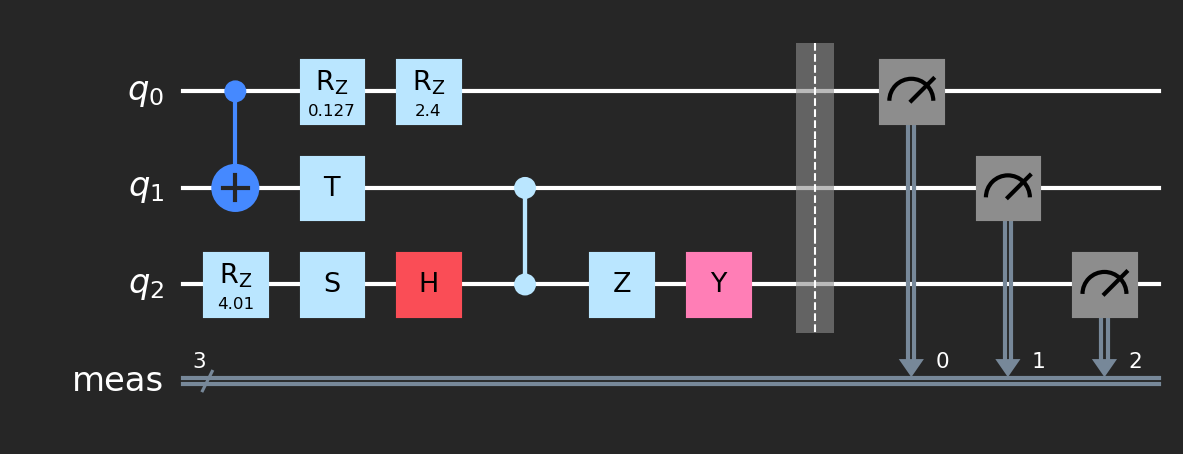

In [19]:
qc = qc_generator(num_qubits = 3, depth = 10, measure = True)

print(qc.depth())

qc.draw()

11


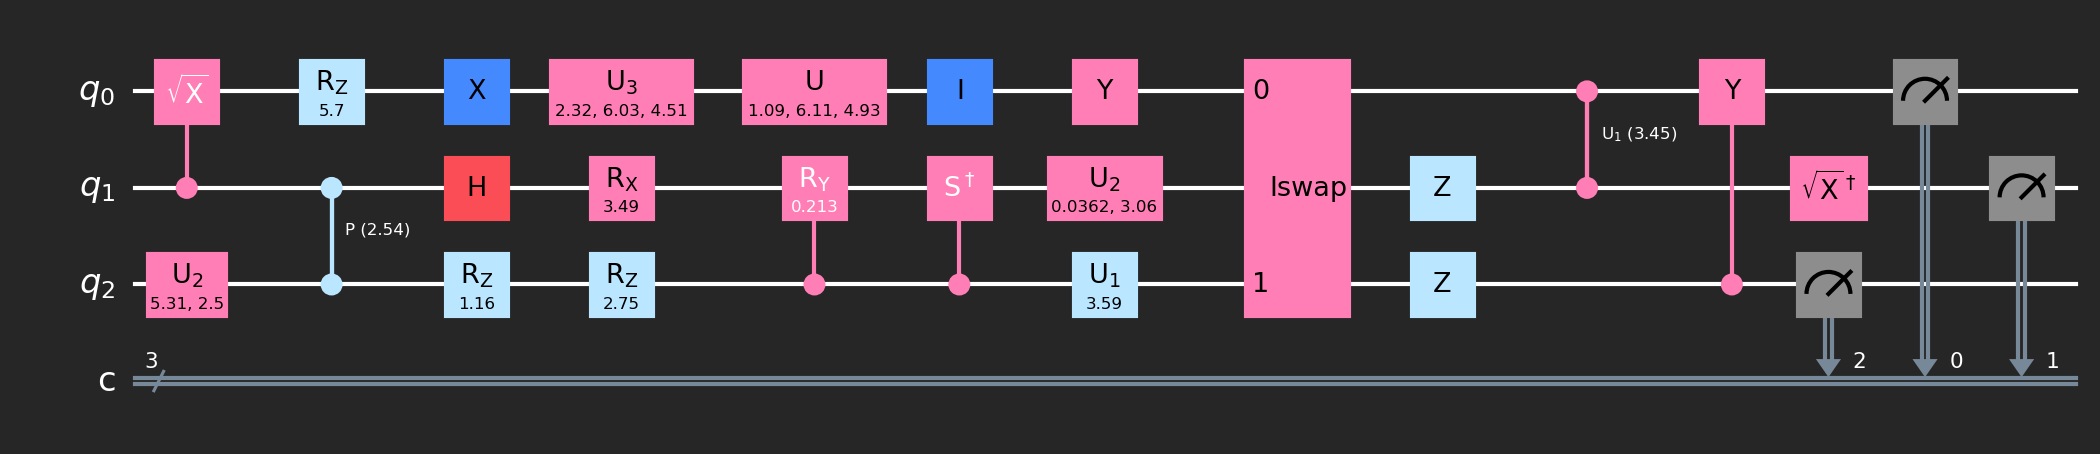

In [15]:
qc = random_circuit(num_qubits = 3, depth = 10, measure = True)

print(qc.depth())

qc.draw()

A função `qc_generator` ja consegue criar o próprio circuito quântico, mas não está com a contagem correta de depth. 

In [ ]:
def qc_generator_layered(num_qubits, depth, clifford = False, gates = None, measure = None, gate_density = 0.8, one_qubit_distribution = 0.7) :

    """
    Gera um circuito quântico aleatório utilizando gates de 1 ou 2 qubits apenas.
        
    Parâmetros:
        num_qubits (int): número de qubits
        depth (int): profundidade
        clifford (bool): se True, usa apenas portas Clifford
        gates (list) : Conjunto de gates para utilizar -> [["1 qubit gates"], ["2 qubit gates"]]
        measure (bool) : Medir ao final.
        gate_density (float): Probabilidade (0 a 1) de adicionar um gate em um qubit disponível em cada camada. Densidade de gates do circuito.
        one_qubit_distribution (float): Probabilidade (0 a 1) de o gate a ser adicionado ser de 1 qubit (vs. 2 qubits).
    
    Retorna: QuantumCircuit
    
    Todo: Incluir 3+ qubit gates. 
    """

    if gates == None:

        if clifford:
            one_qubit_gates = ['h', 's', 'x', 'y', 'z']
            two_qubit_gates = ['cx']
            
        else:
            one_qubit_gates = ['h', 's', 'x', 'y', 'z', 't', 'rx', 'ry', 'rz']
            two_qubit_gates = ['cx', 'cz']
            
    else : 
        
        one_qubit_gates, two_qubit_gates = gates[0], gates[1]
        
    qc = QuantumCircuit(num_qubits)
    
    for a in range(depth):
        
        if random.random() < one_qubit_distribution:
            
            gate_choice = one_qubit_gates[random.randint(0, len(one_qubit_gates) - 1)]
            
            qubit_choice = random.randint(0, num_qubits - 1)
            
            if gate_choice in (gates_config := ['rx', 'ry', 'rz']):
                
                angle_choice = random.uniform(0, 2*pi)
                
                getattr(qc, gate_choice)(angle_choice, qubit_choice)
            
            else : 
                
                getattr(qc, gate_choice)(qubit_choice)
                
        else : 
            
            gate_choice = two_qubit_gates[random.randint(0, len(two_qubit_gates) - 1)]
            
            qubit_1, qubit_2  = random.sample(range(num_qubits), 2)
            
            getattr(qc, gate_choice)(qubit_1, qubit_2)
    
    if measure : 
        
        qc.measure_all()
        
    return qc